# Notebook 4: Evaluate Controllers

**Goal:** Load the trained ML models and the baseline controller, run them on predefined evaluation scenarios, calculate performance metrics, and generate comparison plots to demonstrate the ML agent's effectiveness.

## 1. Setup and Imports

Import necessary libraries and custom modules.

In [1]:
# Cell 1: Setup and Imports
import sys
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import logging # For cleaner output from evaluation engine
import traceback # For error printing
import math # For math.sin/cos in observation construction
from typing import Dict, Optional, Any, List # For type hinting

# --- Add project root to sys.path ---
notebook_dir = os.getcwd() # Should be AGARTECHdiss_simplified/notebooks
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added '{project_root}' to sys.path")

# --- Import project modules ---
try:
    from simulator.core import GreenhouseSimulator, SensorSnapshot, ControlState, vapor_pressure_deficit
    from controllers.baseline import BaselineController
    from controllers.smart_ml_agent import SmartMLAgent # Loads SB3 models
    # Import constants from scenarios.py that are needed by run_eval_scenario
    from evaluation.scenarios import get_scenario, list_scenarios, EVAL_DT_MIN, OBSERVATION_FEATURE_ORDER
    from evaluation.metrics import calculate_metrics
    # Import plotting utils if created, otherwise plot directly
    try:
        from evaluation.plot_utils import setup_plotting_style, create_comparison_figure
        PLOT_UTILS_AVAILABLE = True
        print("Imported plot_utils.")
    except ImportError:
        print("WARN: evaluation/plot_utils.py not found or has errors. Plotting will be done directly if needed.")
        PLOT_UTILS_AVAILABLE = False

    print("Successfully imported project modules.")
except ImportError as e:
    print(f"ERROR: Failed to import modules: {e}")
    print("Ensure previous notebooks ran successfully and files exist.")
    print("Make sure all dependencies are installed.")
    # Define dummy classes/variables if imports fail, to allow notebook to load
    # Corrected dummy definitions:
    if 'GreenhouseSimulator' not in locals():
        class GreenhouseSimulator: pass
    if 'SensorSnapshot' not in locals():
        class SensorSnapshot: pass
    if 'ControlState' not in locals():
        class ControlState: pass
    if 'BaselineController' not in locals():
        class BaselineController: pass
    if 'SmartMLAgent' not in locals():
        class SmartMLAgent: pass
    if 'get_scenario' not in locals():
        def get_scenario(x): return {}
    if 'list_scenarios' not in locals():
        def list_scenarios(): return []
    if 'EVAL_DT_MIN' not in locals():
        EVAL_DT_MIN = 5 # Default if not imported
    if 'OBSERVATION_FEATURE_ORDER' not in locals():
        OBSERVATION_FEATURE_ORDER = [] # Default if not imported
    if 'calculate_metrics' not in locals():
        def calculate_metrics(x,y): return {} # Dummy
    PLOT_UTILS_AVAILABLE = False


# --- Configure Logging and Plotting ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(module)s - %(message)s')
if PLOT_UTILS_AVAILABLE:
    setup_plotting_style(context='notebook') # Use notebook context for plot sizes
else:
    sns.set_theme(style="ticks", context="notebook")
    plt.rcParams['figure.figsize'] = (14, 7) # Default figure size if not using plot_utils

# --- Define Paths ---
MODEL_SAVE_DIR = os.path.abspath(os.path.join(project_root, "evaluation", "trained_models"))
CITY_CONFIG_DIR = os.path.abspath(os.path.join(project_root, "simulator", "city_configs"))
FIGURE_DIR = os.path.abspath(os.path.join(project_root, "figures"))
os.makedirs(FIGURE_DIR, exist_ok=True)

print(f"Model Save Directory: {MODEL_SAVE_DIR}")
print(f"Figure Directory: {FIGURE_DIR}")

2025-05-06 20:40:53,428 - INFO - plot_utils - Plotting style set to 'ticks', context 'notebook'.


INFO: Gymnasium and Stable-Baselines3 (PPO) imported successfully in smart_ml_agent.
Imported plot_utils.
Successfully imported project modules.
Model Save Directory: /Users/jaabirahmed/Documents/AGARFARM/evaluation/trained_models
Figure Directory: /Users/jaabirahmed/Documents/AGARFARM/figures


## 2. Helper Function for Running an Evaluation Scenario

This function will take a city, scenario ID, a controller instance, and its name, then run the simulation and return the history.

In [2]:
# Cell 2: Evaluation Scenario Runner Function

def run_eval_scenario(
    city_name: str,
    scenario_id: str,
    controller_instance: Any, # Can be BaselineController or SmartMLAgent
    controller_display_name: str, # For logging/tagging results e.g., "Baseline", "ML Normal"
    dt_min: int = EVAL_DT_MIN # Use dt_min from scenarios.py
) -> Optional[pd.DataFrame]:
    """Runs a simulation for one controller on one scenario and returns history."""
    logging.info(f"  Starting run: City={city_name}, Scenario={scenario_id}, Controller={controller_display_name}")
    start_run_time = time.time()
    history = []

    try:
        # --- Setup ---
        scenario_config = get_scenario(scenario_id) # Raises ValueError if not found
        city_config_path = os.path.join(CITY_CONFIG_DIR, f"{city_name}.yaml")
        if not os.path.exists(city_config_path):
            raise FileNotFoundError(f"City config not found: {city_config_path}")
        with open(city_config_path, 'r') as f: city_config = yaml.safe_load(f)

        # Use targets from scenario if defined, else from city config
        target_ranges = scenario_config.get('target_ranges', {})
        if not target_ranges: # If scenario has no targets, load city defaults
             target_ranges = {k.replace('default_target_',''): v for k, v in city_config.items() if k.startswith('default_target_')}
        # Ensure all target keys are present
        for key_base in ['t_c', 'rh', 'sm']:
            if f'{key_base}_min' not in target_ranges or f'{key_base}_max' not in target_ranges:
                raise ValueError(f"Missing target range keys for {key_base} in scenario/city config.")


        sim_month = scenario_config.get('sim_month', city_config.get('month', 7))
        initial_state_override = scenario_config.get('initial_state', None)
        sim = GreenhouseSimulator(
            city_config_path=city_config_path,
            init_state=initial_state_override,
            sim_month=sim_month
        )
        target_temp_midpoint = (target_ranges['t_c_min'] + target_ranges['t_c_max']) / 2.0

        # Maintenance Scenario Logic
        is_maintenance = scenario_config.get('is_maintenance', False)
        override_start = scenario_config.get('override_start_step', -1)
        override_end = override_start + scenario_config.get('override_duration_steps', 0)
        override_actions_dict = scenario_config.get('override_actuator_states', {})
        fixed_override_control = ControlState(**override_actions_dict) if is_maintenance else None

        # --- Simulation Loop ---
        snapshot = SensorSnapshot(sim.temp_c, sim.rh, sim.sm, vapor_pressure_deficit(sim.temp_c, sim.rh), sim.rain_tank)
        total_ticks = scenario_config['duration_steps']

        for tick in range(total_ticks):
            # --- Get State/Observation ---
            outside_temp = sim.get_outside_temp()
            outside_rh = sim.outside_rh # Assuming constant from config
            sim_time_min = sim.time_min
            current_hour = int((sim_time_min % 1440) // 60)
            event_flags = {
                 "is_raining": int(sim._is_scheduled_raining() or sim.is_rainstorm_active()),
                 "spike_active": int(sim.is_spike_active()),
                 "rainstorm_active": int(sim.is_rainstorm_active()),
                 "power_off_active": int(sim.is_power_off_active()),
            }

            # --- Determine Action ---
            controls: ControlState
            run_override = False
            if is_maintenance and override_start <= tick < override_end:
                controls = fixed_override_control
                run_override = True
            elif isinstance(controller_instance, SmartMLAgent):
                # Construct observation array for ML agent
                observation_dict = {
                    **snapshot.to_dict(), 'outside_temp': outside_temp, 'outside_rh': outside_rh,
                    'sin_hour': math.sin(2 * math.pi * current_hour / 24.0),
                    'cos_hour': math.cos(2 * math.pi * current_hour / 24.0),
                    **event_flags, **{'target_' + k: v for k, v in target_ranges.items()}
                }
                try:
                    # Ensure all features in OBSERVATION_FEATURE_ORDER are present in observation_dict
                    missing_obs_features = [f for f in OBSERVATION_FEATURE_ORDER if f not in observation_dict]
                    if missing_obs_features:
                        raise KeyError(f"Missing features for ML observation: {missing_obs_features}")
                    observation_np = np.array([observation_dict[f] for f in OBSERVATION_FEATURE_ORDER], dtype=np.float32)
                    controls = controller_instance.get_action(observation_np)
                except KeyError as e:
                     logging.error(f"KeyError for ML observation at tick {tick}: {e}. Using default controls.")
                     controls = ControlState()
                except Exception as ml_e:
                     logging.error(f"ML controller failed at tick {tick}: {ml_e}. Using default controls.", exc_info=True)
                     controls = ControlState()

            elif isinstance(controller_instance, BaselineController):
                controls = controller_instance.get_controls(snapshot, outside_temp, outside_rh, event_flags['is_raining'])
            else: # Fallback
                logging.warning(f"Unknown controller type at tick {tick}. Using default OFF controls.")
                controls = ControlState()

            # --- Log State BEFORE Step ---
            current_resources = sim.resource_totals()
            log_entry = { "tick": tick, "city": city_name, "scenario": scenario_id, "controller_name": controller_display_name,
                         **snapshot.to_dict(), "outside_temp": outside_temp, "outside_rh": outside_rh,
                         "fan": int(controls.fan), "ac": int(controls.ac), "vent": int(controls.vent), "irrigation": int(controls.irrigation),
                         "kwh": current_resources["kwh"], "water_l": current_resources["water_l"], **event_flags, "override_active": int(run_override) }
            history.append(log_entry)

            # --- Step Simulator ---
            snapshot = sim.step(dt_min=dt_min, controls=controls, target_temp_midpoint=target_temp_midpoint)

        # Add final state to history
        current_resources = sim.resource_totals()
        log_entry = { "tick": total_ticks, "city": city_name, "scenario": scenario_id, "controller_name": controller_display_name,
                     **snapshot.to_dict(), "outside_temp": sim.get_outside_temp(), "outside_rh": sim.outside_rh,
                     "fan": np.nan, "ac": np.nan, "vent": np.nan, "irrigation": np.nan, # No action at final step
                     "kwh": current_resources["kwh"], "water_l": current_resources["water_l"], **event_flags, "override_active": np.nan }
        history.append(log_entry)

        end_time = time.time()
        logging.info(f"    -> Finished run for {controller_display_name} in {end_time - start_run_time:.2f}s. Logged {len(history)} ticks.")
        return pd.DataFrame(history)

    except Exception as e:
        logging.error(f"ERROR running scenario {city_name}/{scenario_id}/{controller_display_name}: {e}", exc_info=True)
        return None # Return None on failure

## 3. Load Controllers

Instantiate the baseline controller and load the 4 pre-trained PPO models using the `SmartMLAgent` class.

In [3]:
# Cell 3: Load Controllers
print("--- Loading Controllers ---")

# --- Baseline Controllers ---
# Create baseline instances for each city, using their default targets for context
baseline_controllers = {}
ml_controllers = {} # Store loaded ML agents
model_files_exist = True # Flag to track if all models are found

try:
    for city_name in ['oslo', 'riyadh']:
        city_config_path = os.path.join(CITY_CONFIG_DIR, f"{city_name}.yaml")
        with open(city_config_path, 'r') as f: city_cfg = yaml.safe_load(f)
        city_targets = {k.replace('default_target_',''): v for k, v in city_cfg.items() if k.startswith('default_target_')}

        # Create a baseline for 'normal' comparison and one for 'eco' comparison
        baseline_controllers[f'{city_name}_normal_baseline'] = BaselineController(city_config=city_cfg, target_ranges=city_targets, eco_mode=False)
        baseline_controllers[f'{city_name}_eco_baseline'] = BaselineController(city_config=city_cfg, target_ranges=city_targets, eco_mode=True)
    print("Baseline controllers instantiated.")
except Exception as e:
    print(f"ERROR instantiating baseline controllers: {e}")
    traceback.print_exc()


# --- ML Controllers ---
for city_code_short, city_name_full in [('o', 'oslo'), ('r', 'riyadh')]:
    for mode in ['normal', 'eco']:
        model_suffix = f"{city_code_short}_{mode}" # e.g., o_normal
        model_filename = f"ppo_agent_{model_suffix}.zip"
        vec_norm_filename = f"vecnormalize_{model_suffix}.pkl"
        model_filepath = os.path.join(MODEL_SAVE_DIR, model_filename)
        vec_norm_filepath = os.path.join(MODEL_SAVE_DIR, vec_norm_filename)

        controller_key = f"ML {city_name_full.capitalize()} {mode.capitalize()}" # e.g., "ML Oslo Normal"

        if not os.path.exists(model_filepath):
            print(f"ERROR: Model file not found: {model_filepath}. Cannot load {controller_key}.")
            ml_controllers[controller_key] = None
            model_files_exist = False
            continue

        vec_norm_path_arg = vec_norm_filepath if os.path.exists(vec_norm_filepath) else None
        if vec_norm_path_arg is None:
             print(f"WARN: VecNormalize file not found: {vec_norm_filepath}. ML agent {controller_key} will run without external normalization (may perform poorly if trained with it).")

        try:
            agent = SmartMLAgent(model_path=model_filepath, vec_normalize_path=vec_norm_path_arg)
            if agent.model is None: # Check if loading failed inside SmartMLAgent
                 print(f"ERROR: Failed to load model correctly for {controller_key}")
                 ml_controllers[controller_key] = None
                 model_files_exist = False
            else:
                 ml_controllers[controller_key] = agent
                 print(f"Successfully loaded: {controller_key}")
        except Exception as e:
             print(f"ERROR loading {controller_key}: {e}")
             ml_controllers[controller_key] = None
             model_files_exist = False


if not model_files_exist:
    print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    print("! WARNING: One or more ML model/stats files were not found or failed load. !")
    print("!          Please ensure Notebook 03 (Training) completed successfully     !")
    print("!          and files are in evaluation/trained_models/.                    !")
    print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

--- Loading Controllers ---
Baseline controllers instantiated.


2025-05-06 20:40:54,211 - INFO - smart_ml_agent - ML Model loaded successfully from /Users/jaabirahmed/Documents/AGARFARM/evaluation/trained_models/ppo_agent_o_normal.zip using PPO.load()
2025-05-06 20:40:54,212 - INFO - smart_ml_agent - Attempting to load VecNormalize stats from /Users/jaabirahmed/Documents/AGARFARM/evaluation/trained_models/vecnormalize_o_normal.pkl...
2025-05-06 20:40:54,213 - INFO - smart_ml_agent - VecNormalize stats loaded successfully from /Users/jaabirahmed/Documents/AGARFARM/evaluation/trained_models/vecnormalize_o_normal.pkl
2025-05-06 20:40:54,220 - INFO - smart_ml_agent - ML Model loaded successfully from /Users/jaabirahmed/Documents/AGARFARM/evaluation/trained_models/ppo_agent_o_eco.zip using PPO.load()
2025-05-06 20:40:54,220 - INFO - smart_ml_agent - Attempting to load VecNormalize stats from /Users/jaabirahmed/Documents/AGARFARM/evaluation/trained_models/vecnormalize_o_eco.pkl...
2025-05-06 20:40:54,221 - INFO - smart_ml_agent - VecNormalize stats loade

Successfully loaded: ML Oslo Normal
Successfully loaded: ML Oslo Eco
Successfully loaded: ML Riyadh Normal
Successfully loaded: ML Riyadh Eco


## 4. Run Evaluation Scenario and Compare

Choose a scenario and run it with the baseline and the corresponding ML controllers. Calculate metrics and generate plots.

2025-05-06 20:40:54,251 - INFO - 2019045355 -   Starting run: City=riyadh, Scenario=riyadh_summer_cooling, Controller=Baseline (Normal Setting)
2025-05-06 20:40:54,261 - INFO - 2019045355 -     -> Finished run for Baseline (Normal Setting) in 0.01s. Logged 1441 ticks.
2025-05-06 20:40:54,265 - INFO - 2019045355 -   Starting run: City=riyadh, Scenario=riyadh_summer_cooling, Controller=Baseline (Eco Setting)
2025-05-06 20:40:54,274 - INFO - 2019045355 -     -> Finished run for Baseline (Eco Setting) in 0.01s. Logged 1441 ticks.
2025-05-06 20:40:54,278 - INFO - 2019045355 -   Starting run: City=riyadh, Scenario=riyadh_summer_cooling, Controller=ML Normal



--- Evaluating Scenario: riyadh_summer_cooling ---


2025-05-06 20:40:54,433 - INFO - 2019045355 -     -> Finished run for ML Normal in 0.15s. Logged 1441 ticks.
2025-05-06 20:40:54,437 - INFO - 2019045355 -   Starting run: City=riyadh, Scenario=riyadh_summer_cooling, Controller=ML Eco
2025-05-06 20:40:54,587 - INFO - 2019045355 -     -> Finished run for ML Eco in 0.15s. Logged 1441 ticks.
2025-05-06 20:40:54,600 - INFO - plot_utils - Generating comparison plot for riyadh - riyadh_summer_cooling...
2025-05-06 20:40:54,601 - INFO - plot_utils - Plotting style set to 'ticks', context 'talk'.



--- Calculating Metrics ---

Metrics for Baseline (Normal Setting):
  mean_t_c: 26.259
  mean_rh: 55.635
  mean_sm: 9.052
  mean_vpd: 1.514
  pct_time_t_c_out: 9.854
  pct_time_rh_out: 60.167
  pct_time_sm_out: 95.767
  mae_t_c: 0.043
  mae_rh: 1.143
  mae_sm: 26.031
  total_kwh: 8.482
  total_water_l: 149.000
  avg_usage_fan: 0.165
  avg_usage_ac: 0.142
  avg_usage_vent: 0.126
  avg_usage_irrigation: 0.103

Metrics for Baseline (Eco Setting):
  mean_t_c: 26.260
  mean_rh: 52.975
  mean_sm: 7.221
  mean_vpd: 1.604
  pct_time_t_c_out: 1.874
  pct_time_rh_out: 13.255
  pct_time_sm_out: 92.713
  mae_t_c: 0.005
  mae_rh: 0.056
  mae_sm: 27.943
  total_kwh: 11.585
  total_water_l: 149.000
  avg_usage_fan: 0.000
  avg_usage_ac: 0.208
  avg_usage_vent: 0.133
  avg_usage_irrigation: 0.103

Metrics for ML Normal:
  mean_t_c: 24.759
  mean_rh: 64.740
  mean_sm: 34.453
  mean_vpd: 1.098
  pct_time_t_c_out: 2.221
  pct_time_rh_out: 74.740
  pct_time_sm_out: 75.989
  mae_t_c: 0.028
  mae_rh: 14.23

2025-05-06 20:40:55,076 - INFO - plot_utils - Comparison plot saved to /Users/jaabirahmed/Documents/AGARFARM/figures/comparison_riyadh_riyadh_summer_cooling.png


Plot saved as 'comparison_riyadh_riyadh_summer_cooling.png' in '/Users/jaabirahmed/Documents/AGARFARM/figures'


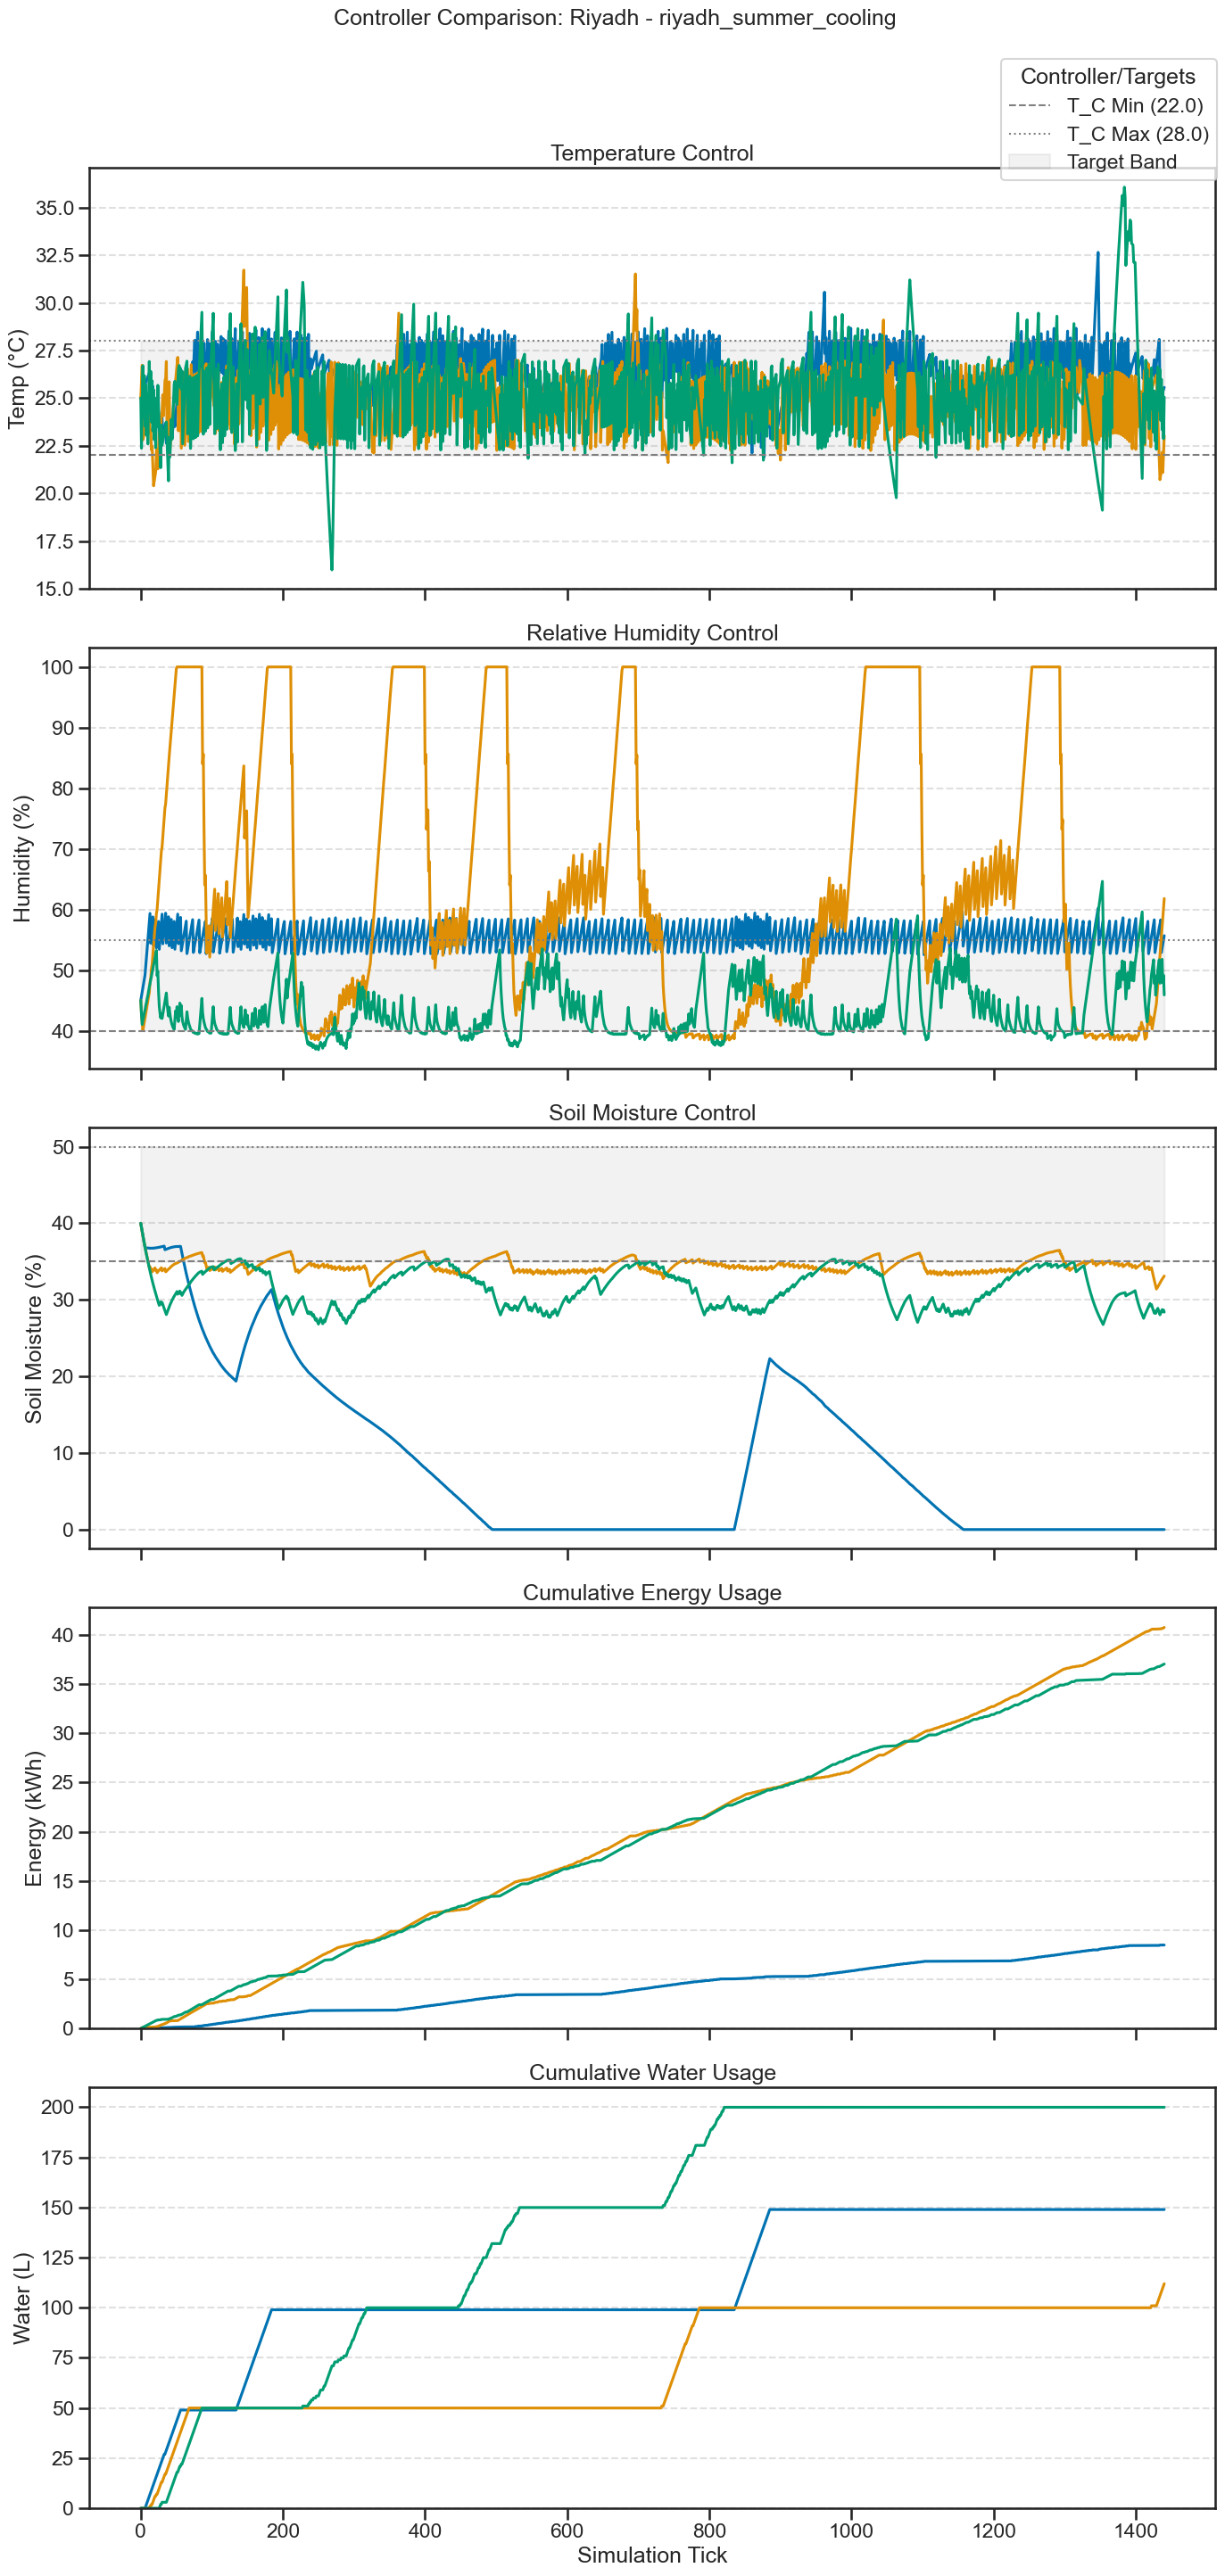

In [4]:
# Cell 4: Run Evaluation Scenario and Compare

# --- Select Scenario for Evaluation ---
# scenario_id_to_run = "oslo_summer_normal"
scenario_id_to_run = "riyadh_summer_cooling"
# scenario_id_to_run = "oslo_winter_heating"
# scenario_id_to_run = "riyadh_winter_normal"
# scenario_id_to_run = "riyadh_winter_low_water"
# scenario_id_to_run = "oslo_maintenance_recovery" # For offline analysis

print(f"\n--- Evaluating Scenario: {scenario_id_to_run} ---")

# Initialize variables that will be used in the diagnostics cell
city = "N/A"
metrics_df = pd.DataFrame()
metrics_results = {}
plot_filename = None # For diagnostics

try:
    scenario_config = get_scenario(scenario_id_to_run)
    city = scenario_config['city'] # Assign city for diagnostics
    eval_targets = scenario_config.get('target_ranges', {})
    if not eval_targets: # If scenario has no targets, load city defaults
        city_config_path_eval = os.path.join(CITY_CONFIG_DIR, f"{city}.yaml")
        with open(city_config_path_eval, 'r') as f: city_cfg_eval = yaml.safe_load(f)
        eval_targets = {k.replace('default_target_',''): v for k, v in city_cfg_eval.items() if k.startswith('default_target_')}

    # --- Determine which controllers to run based on city ---
    # For this notebook, we compare ML Normal vs Baseline Normal, and ML Eco vs Baseline Eco
    baseline_normal_instance = baseline_controllers.get(f"{city}_normal_baseline")
    baseline_eco_instance = baseline_controllers.get(f"{city}_eco_baseline")

    ml_normal_agent = ml_controllers.get(f"ML {city.capitalize()} Normal")
    ml_eco_agent = ml_controllers.get(f"ML {city.capitalize()} Eco")

    # --- Store history and metrics ---
    history_results = {}
    # metrics_results is already initialized

    # --- Run Baseline (Normal Mode for comparison with ML Normal) ---
    if baseline_normal_instance:
        history_results['Baseline (Normal Setting)'] = run_eval_scenario(city, scenario_id_to_run, baseline_normal_instance, 'Baseline (Normal Setting)')
    else:
        print(f"Baseline Normal controller for {city} not found.")
        history_results['Baseline (Normal Setting)'] = None

    # --- Run Baseline (Eco Mode for comparison with ML Eco) ---
    if baseline_eco_instance:
        history_results['Baseline (Eco Setting)'] = run_eval_scenario(city, scenario_id_to_run, baseline_eco_instance, 'Baseline (Eco Setting)')
    else:
        print(f"Baseline Eco controller for {city} not found.")
        history_results['Baseline (Eco Setting)'] = None


    # --- Run ML Normal ---
    if ml_normal_agent:
        history_results['ML Normal'] = run_eval_scenario(city, scenario_id_to_run, ml_normal_agent, 'ML Normal')
    else:
        print(f"ML Normal agent for {city} not loaded. Skipping run.")
        history_results['ML Normal'] = None

    # --- Run ML Eco ---
    if ml_eco_agent:
        history_results['ML Eco'] = run_eval_scenario(city, scenario_id_to_run, ml_eco_agent, 'ML Eco')
    else:
        print(f"ML Eco agent for {city} not loaded. Skipping run.")
        history_results['ML Eco'] = None

    # --- Calculate Metrics ---
    print("\n--- Calculating Metrics ---")
    for name, hist_df in history_results.items():
        if hist_df is not None and not hist_df.empty:
            metrics_results[name] = calculate_metrics(hist_df, eval_targets)
            print(f"\nMetrics for {name}:")
            if metrics_results[name] and metrics_results[name].get('error') is None : # Check for error key
                 for key, value in metrics_results[name].items():
                     if key != 'error': # Don't print the error key itself if it's None
                         print(f"  {key}: {value:.3f}" if isinstance(value, (int, float)) else f"  {key}: {value}")
            elif metrics_results[name]:
                 print(f"  Error calculating metrics: {metrics_results[name].get('error')}")
            else:
                 print("  Metrics calculation returned None.")
        else:
            print(f"\nMetrics for {name}: No data available or simulation failed.")
            metrics_results[name] = {"error": "No simulation data"} # Ensure key exists with error

    # --- Create Comparison Table (Example) ---
    print("\n--- Metrics Comparison Summary ---")
    # Filter out None results or results with errors before creating DataFrame
    valid_metrics_for_df = {k: v for k, v in metrics_results.items() if v is not None and v.get('error') is None}
    if valid_metrics_for_df:
        metrics_df = pd.DataFrame(valid_metrics_for_df).T
        cols_to_show = ['total_kwh', 'total_water_l', 'mae_t_c', 'mae_rh', 'mae_sm', 'pct_time_t_c_out', 'pct_time_rh_out', 'pct_time_sm_out', 'avg_usage_ac', 'avg_usage_fan', 'avg_usage_vent', 'avg_usage_irrigation']
        # Filter to only show columns that actually exist in the DataFrame
        metrics_df_display = metrics_df[[col for col in cols_to_show if col in metrics_df.columns]]
        print(metrics_df_display.to_markdown(floatfmt=".2f"))
    else:
        print("No valid metrics calculated for comparison table.")

    # --- Generate and Save Plots ---
    print("\n--- Generating Comparison Plot ---")
    if PLOT_UTILS_AVAILABLE:
        # Prepare history_dfs for plotting, ensuring keys match what plot_utils expects
        # For example, if plot_utils expects 'Baseline', 'ML Normal', 'ML Eco'
        plot_history_dfs = {
            'Baseline': history_results.get('Baseline (Normal Setting)'), # Choose one baseline for main plot
            'ML Normal': history_results.get('ML Normal'),
            'ML Eco': history_results.get('ML Eco')
        }
        plot_filename = create_comparison_figure(
            history_dfs=plot_history_dfs,
            scenario_id=scenario_id_to_run,
            city=city,
            target_ranges=eval_targets,
            save_dir=FIGURE_DIR
        )
        if plot_filename:
            print(f"Plot saved as '{plot_filename}' in '{FIGURE_DIR}'")
            # Display plot in notebook
            from IPython.display import Image, display
            display(Image(filename=os.path.join(FIGURE_DIR, plot_filename)))
        else:
            print("Plot generation failed or returned no filename.")
    else:
        print("Plotting utilities not available. Manual plotting would be needed here.")
        # Example: You could add direct matplotlib plotting here if plot_utils is not used
        # fig, axes = plt.subplots(3,1, figsize=(15,15))
        # for name, df_hist in history_results.items():
        #    if df_hist is not None and not df_hist.empty:
        #        axes[0].plot(df_hist['tick'], df_hist['t_c'], label=name)
        # axes[0].set_title('Temperature')
        # axes[0].legend()
        # plt.show()


except FileNotFoundError as e:
    print(f"ERROR: Configuration file not found for evaluation: {e}")
    traceback.print_exc()
except ValueError as e:
    print(f"ERROR: Value error during evaluation setup: {e}")
    traceback.print_exc()
except Exception as e:
    print(f"UNEXPECTED ERROR during evaluation: {e}")
    traceback.print_exc()


## 5. Repeat Evaluation for Other Scenarios (Optional)

Copy and paste the cells from Section 4, changing the `scenario_id_to_run` variable to evaluate performance under different conditions (e.g., a winter scenario, a low-water scenario, or the maintenance scenario).

In [5]:
# Cell 5a: Evaluate another scenario (e.g., Oslo Winter)
# scenario_id_to_run_2 = "oslo_winter_heating"
# print(f"\n--- Evaluating Scenario: {scenario_id_to_run_2} ---")
# # --- Ensure variables are reset or correctly scoped if copying Cell 4 logic ---
# # city_2 = get_scenario(scenario_id_to_run_2)['city']
# # eval_targets_2 = ...
# # baseline_normal_instance_2 = ...
# # ... (copy and adapt the logic from Cell 4, using new variable names like city_2, etc.) ...
# # ... or re-run Cell 4 after changing scenario_id_to_run at the top of Cell 4 ...

## 6. Conclusion and Analysis

Summarize the key findings from the evaluations.
- Did the ML controllers outperform the baseline? By how much (quantify using metrics)?
- Was there a clear difference between the Normal and Eco ML modes in terms of target adherence vs. resource use?
- How did performance vary across different scenarios (e.g., summer vs. winter)?
- Discuss any limitations or interesting observations from the results.

In [6]:
# Cell 6: Diagnostics Summary for Review
# --- Notebook 04 Diagnostics Cell ---
import pandas as pd
import numpy as np
from datetime import datetime
import os
import traceback

print("--- Notebook 04 Diagnostics ---")
print(f"Timestamp: {datetime.now()}")

# Check which controllers were loaded/available for the evaluated scenario
print("\nController Loading Status (for last evaluated scenario):")
try:
    # Check if the variables from the last run in Cell 4 exist
    baseline_loaded_eval = 'baseline_normal_instance' in locals() and baseline_normal_instance is not None
    ml_normal_loaded_eval = 'ml_normal_agent' in locals() and ml_normal_agent is not None and hasattr(ml_normal_agent, 'model') and ml_normal_agent.model is not None
    ml_eco_loaded_eval = 'ml_eco_agent' in locals() and ml_eco_agent is not None and hasattr(ml_eco_agent, 'model') and ml_eco_agent.model is not None
    print(f"- Baseline Instance Used: {baseline_loaded_eval}")
    print(f"- ML Normal Agent Used: {ml_normal_loaded_eval}")
    print(f"- ML Eco Agent Used: {ml_eco_loaded_eval}")
except NameError:
    print("- Controller loading status variables not found (evaluation likely didn't run fully in this session).")
except Exception as e_load_check:
    print(f"- Error checking controller loading status: {e_load_check}")


# Report on the primary scenario evaluated in the notebook
scenario_info = "N/A"
city_info = "N/A"
try:
    if 'scenario_id_to_run' in locals(): scenario_info = scenario_id_to_run
    if 'city' in locals(): city_info = city # 'city' should be defined in the scope of Cell 4
except NameError:
    pass # Variables might not be defined if Cell 4 didn't run
print(f"\nEvaluation Summary for Scenario: '{scenario_info}' (City: {city_info})")

# Check if the metrics DataFrame was created and print summary
metrics_calculated = False
if 'metrics_df' in locals() and isinstance(metrics_df, pd.DataFrame) and not metrics_df.empty:
    print("\nMetrics Comparison Table (Markdown Format):")
    try:
        # Ensure only numeric columns are formatted if floatfmt is used, or handle non-numeric gracefully
        # For simplicity, we'll rely on pandas' default string conversion for non-float columns.
        print(metrics_df.to_markdown(floatfmt=".2f"))
        metrics_calculated = True
    except Exception as e:
        print(f"- Error formatting metrics table: {e}")
        traceback.print_exc()
else:
    print("\nMetrics Comparison Table: Not generated or failed.")

# --- Calculate and Print Savings vs Baseline ---
print("\nResource Savings vs Baseline (Normal vs ML Normal, Eco vs ML Eco):")
if metrics_calculated and 'metrics_results' in locals() and isinstance(metrics_results, dict):
    try:
        # Compare ML Normal vs Baseline (Normal Setting)
        baseline_normal_metrics = metrics_results.get('Baseline (Normal Setting)', {})
        ml_normal_metrics = metrics_results.get('ML Normal', {})

        if baseline_normal_metrics and baseline_normal_metrics.get('total_kwh') is not None and baseline_normal_metrics.get('total_water_l') is not None:
            base_kwh_norm = baseline_normal_metrics['total_kwh']
            base_h2o_norm = baseline_normal_metrics['total_water_l']
            if ml_normal_metrics and ml_normal_metrics.get('total_kwh') is not None and ml_normal_metrics.get('total_water_l') is not None:
                norm_kwh_sav = base_kwh_norm - ml_normal_metrics['total_kwh']
                norm_h2o_sav = base_h2o_norm - ml_normal_metrics['total_water_l']
                norm_kwh_pct = (norm_kwh_sav / base_kwh_norm * 100) if base_kwh_norm != 0 else (0 if norm_kwh_sav == 0 else float('inf'))
                norm_h2o_pct = (norm_h2o_sav / base_h2o_norm * 100) if base_h2o_norm != 0 else (0 if norm_h2o_sav == 0 else float('inf'))
                print(f"- ML Normal vs Baseline (Normal): Energy={norm_kwh_sav:.2f} kWh ({norm_kwh_pct:.1f}%), Water={norm_h2o_sav:.2f} L ({norm_h2o_pct:.1f}%)")
            else:
                print(f"- ML Normal: Metrics unavailable for savings calculation vs Normal Baseline.")
        else:
            print("- Baseline (Normal Setting) metrics unavailable for savings calculation.")

        # Compare ML Eco vs Baseline (Eco Setting)
        baseline_eco_metrics = metrics_results.get('Baseline (Eco Setting)', {})
        ml_eco_metrics = metrics_results.get('ML Eco', {})

        if baseline_eco_metrics and baseline_eco_metrics.get('total_kwh') is not None and baseline_eco_metrics.get('total_water_l') is not None:
            base_kwh_eco = baseline_eco_metrics['total_kwh']
            base_h2o_eco = baseline_eco_metrics['total_water_l']
            if ml_eco_metrics and ml_eco_metrics.get('total_kwh') is not None and ml_eco_metrics.get('total_water_l') is not None:
                eco_kwh_sav = base_kwh_eco - ml_eco_metrics['total_kwh']
                eco_h2o_sav = base_h2o_eco - ml_eco_metrics['total_water_l']
                eco_kwh_pct = (eco_kwh_sav / base_kwh_eco * 100) if base_kwh_eco != 0 else (0 if eco_kwh_sav == 0 else float('inf'))
                eco_h2o_pct = (eco_h2o_sav / base_h2o_eco * 100) if base_h2o_eco != 0 else (0 if eco_h2o_sav == 0 else float('inf'))
                print(f"- ML Eco vs Baseline (Eco):       Energy={eco_kwh_sav:.2f} kWh ({eco_kwh_pct:.1f}%), Water={eco_h2o_sav:.2f} L ({eco_h2o_pct:.1f}%)")
            else:
                 print(f"- ML Eco:    Metrics unavailable for savings calculation vs Eco Baseline.")
        else:
            print("- Baseline (Eco Setting) metrics unavailable for savings calculation.")

    except Exception as e:
        print(f"- Error calculating savings: {e}")
        traceback.print_exc()
else:
    print("- Cannot calculate savings (Metrics table not generated or 'metrics_results' missing).")

# Report plot generation status
plot_status = "Unknown"
try:
    if 'plot_filename' in locals() and plot_filename: # Check if variable exists and is not None
        # Construct full path to check existence, assuming FIGURE_DIR is defined
        if 'FIGURE_DIR' in locals() and os.path.isdir(FIGURE_DIR):
            plot_full_path = os.path.join(FIGURE_DIR, plot_filename)
            plot_status = f"Generated ({plot_filename})" if os.path.exists(plot_full_path) else f"File Not Found ({plot_filename})"
        else:
            plot_status = f"Generated ({plot_filename}) - FIGURE_DIR not verified."
    elif 'plot_filename' in locals() and plot_filename is None: # If function returned None
        plot_status = "Failed (plot_utils returned None)"
    else: # Variable not defined at all
        plot_status = "Not generated or filename variable missing"
except NameError:
    plot_status = "Plotting likely not run or failed before filename assignment"
except Exception as e:
    plot_status = f"Error checking plot status: {e}"

print(f"\nComparison Plot Generation Status: {plot_status}")


print("\n--- End Notebook 04 Diagnostics ---")

--- Notebook 04 Diagnostics ---
Timestamp: 2025-05-06 20:40:55.137937

Controller Loading Status (for last evaluated scenario):
- Baseline Instance Used: True
- ML Normal Agent Used: True
- ML Eco Agent Used: True

Evaluation Summary for Scenario: 'riyadh_summer_cooling' (City: riyadh)

Metrics Comparison Table (Markdown Format):
|                           |   mean_t_c |   mean_rh |   mean_sm |   mean_vpd |   pct_time_t_c_out |   pct_time_rh_out |   pct_time_sm_out |   mae_t_c |   mae_rh |   mae_sm |   total_kwh |   total_water_l |   avg_usage_fan |   avg_usage_ac |   avg_usage_vent |   avg_usage_irrigation |
|:--------------------------|-----------:|----------:|----------:|-----------:|-------------------:|------------------:|------------------:|----------:|---------:|---------:|------------:|----------------:|----------------:|---------------:|-----------------:|-----------------------:|
| Baseline (Normal Setting) |      26.26 |     55.64 |      9.05 |       1.51 |               9.